INFO:root:creating a Pool of 4 workers


Fetching genome arms for expected calculation …
Computing expected for chr1:0-130,000,000 …


/sharehome/dlafonta/miniconda3/envs/open2c-env/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


Expected columns: ['region1', 'region2', 'dist', 'dist_bp', 'contact_frequency', 'n_total', 'n_valid', 'count.sum', 'balanced.sum', 'count.avg', 'balanced.avg', 'balanced.avg.smoothed', 'balanced.avg.smoothed.agg']
Unique region1 values: ['chr1_p' 'chr1_q' 'chr2_p' 'chr2_q' 'chr3_p' 'chr3_q' 'chr4_p' 'chr4_q'
 'chr5_p' 'chr5_q']
Expected shape: (12383, 13)
Parsed region: chr1:0-130,000,000
expected_chr shape after filter: (5163, 13)
expected_vals length: 5163
expected_vals NaN count: 235
Fetching observed matrix for chr1:0-130,000,000 …
obs shape: (520, 520), non-NaN count: 217156
Building log2(O/E) matrix …


/tmp/ipykernel_687833/2240554963.py:92: RuntimeWarning: divide by zero encountered in log2
  log2oe = np.log2(oe)


Plotting …


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 17 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 18, 19, 20, 21, 40, 50, 74, 79, 82]
INFO:fontTools.subset:Closed glyph list over 'MATH': 23 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'uni239B', 'uni239C

Saved → DL-20250326-LCHCSeq-HB-2hPD-DpnII-R2-T1__hg38.chr1_0_130000000.250kb.CraneHeatmap_log2OE.pdf


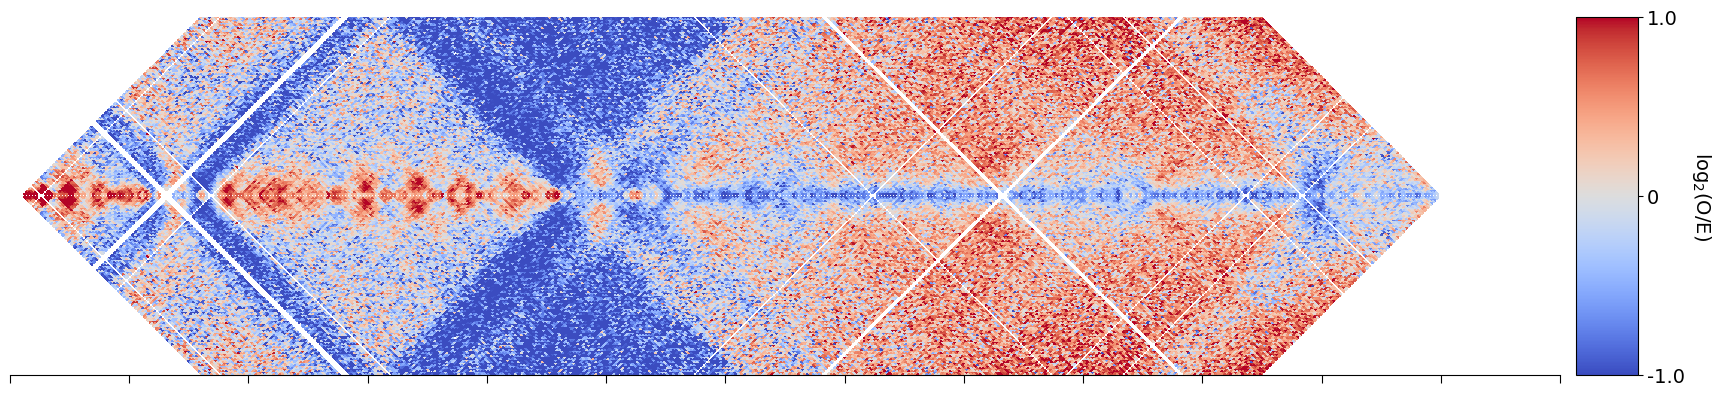

In [18]:
############## HB R2 treatment #############


import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
import bioframe
import os
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import itertools
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType — keeps text editable in Illustrator/Inkscape
mpl.rcParams['svg.fonttype'] = 'none'

# ── CONFIG ────────────────────────────────────────────────────────────────────
resolution  = 250_000
data_dir    = '/MyPath/'
cool_file   = 'DL-20250326-LCHCSeq-HB-2hPD-DpnII-R2-T1__hg38.hg38.exclude1kb.1000.mcool'
region      = 'chr1:0-130,000,000'        # full chromosome
vmin, vmax  = -1.0, 1.0        # log2 O/E colour limits
cmap        = 'coolwarm'
# ─────────────────────────────────────────────────────────────────────────────

# ── LOAD COOLER ───────────────────────────────────────────────────────────────
clr = cooler.Cooler(f'{data_dir}/{cool_file}::/resolutions/{resolution}')

# ── COMPUTE EXPECTED (whole-genome arms table, then trim to chr) ──────────────
print(f"Fetching genome arms for expected calculation …")
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens       = bioframe.fetch_centromeres('hg38')
hg38_arms       = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
hg38_arms       = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

print(f"Computing expected for {region} …")
expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=4, ignore_diags=0)

print("Expected columns:", expected.columns.tolist())
print("Unique region1 values:", expected['region1'].unique()[:10])
print("Expected shape:", expected.shape)


# Parse region into chrom / start / end
parsed = bioframe.parse_region(region, clr.chromsizes)
reg_chrom, reg_start, reg_end = parsed[0], parsed[1], parsed[2]
print(f"Parsed region: {reg_chrom}:{reg_start:,}-{reg_end:,}")

# Keep only rows for our chromosome (match the arm(s) on this chrom)
expected_chr = expected[expected['region1'].str.startswith(reg_chrom)].copy()
print(f"expected_chr shape after filter: {expected_chr.shape}")
expected_vals = np.array(expected_chr['balanced.avg.smoothed'].values, dtype=np.float64)
print(f"expected_vals length: {len(expected_vals)}")
print(f"expected_vals NaN count: {np.sum(np.isnan(expected_vals))}")



# ── FETCH OBSERVED MATRIX (sub-region) ────────────────────────────────────────
print(f"Fetching observed matrix for {region} …")
obs = np.array(clr.matrix(balance=True).fetch(region), dtype=np.float64)
print(f"obs shape: {obs.shape}, non-NaN count: {np.sum(~np.isnan(obs))}")

# ── BUILD log2(O/E) MATRIX ────────────────────────────────────────────────────
print("Building log2(O/E) matrix …")
n = obs.shape[0]
oe = np.full_like(obs, np.nan)

for i in range(n):
    for j in range(i, n):
        d = j - i
        if d < len(expected_vals) and expected_vals[d] > 0:
            v = obs[i, j] / expected_vals[d]
            oe[i, j] = v
            oe[j, i] = v

log2oe = np.log2(oe)
log2oe[~np.isfinite(log2oe)] = np.nan   # Inf / -Inf → NaN

# ── 45-DEGREE ROTATION HELPER ────────────────────────────────────────────────
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, flip_y=False, **kwargs):
    n = matrix_c.shape[0]
    start_pos = [start + resolution * i for i in range(n + 1)]
    t = np.array([[1, 0.5], [-1, 0.5]])
    coords = np.array([(i[1], i[0])
                       for i in itertools.product(start_pos[::-1], start_pos)])
    mat = np.dot(coords, t)
    x = mat[:, 1].reshape(n + 1, n + 1)
    y = mat[:, 0].reshape(n + 1, n + 1)
    if flip_y:
        y = -y
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), **kwargs)
    im.set_rasterized(True)
    return im

# ── PLOT ──────────────────────────────────────────────────────────────────────
print("Plotting …")
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

f, ax = plt.subplots(figsize=(20, 8))

im  = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=False, norm=norm, cmap=cmap)
im2 = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=True,  norm=norm, cmap=cmap)

ax.set_ylim(-30_000_000, 30_000_000)
ax.set_aspect(0.5)

from matplotlib.ticker import MultipleLocator

ax.set_xlim(reg_start, reg_end)

# Tick marks every 10 Mb, no labels
ax.xaxis.set_major_locator(MultipleLocator(10_000_000))
ax.tick_params(axis='x', length=6, labelbottom=False)

# Hide y-axis and all spines
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Show only the bottom spine
for name, spine in ax.spines.items():
    spine.set_visible(name == 'bottom')

# Colorbar — same inset placement as original
cax = inset_axes(ax,
                 width="4%", height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.05, 0., 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('log$_2$(O/E)', rotation=270, labelpad=20, fontsize=14)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f'{vmin:.1f}', '0', f'{vmax:.1f}'])
cbar.ax.tick_params(labelsize=14)

safe = region.replace(':', '_').replace(',', '').replace('-', '_')
out_name = f'{cool_file[:-27]}.{safe}.{resolution//1000}kb.CraneHeatmap_log2OE.pdf'
plt.savefig(out_name, transparent=True, dpi=150)
print(f"Saved → {out_name}")
plt.show()

INFO:root:creating a Pool of 4 workers


Fetching genome arms for expected calculation …
Computing expected for chr1:0-130,000,000 …


/sharehome/dlafonta/miniconda3/envs/open2c-env/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


Expected columns: ['region1', 'region2', 'dist', 'dist_bp', 'contact_frequency', 'n_total', 'n_valid', 'count.sum', 'balanced.sum', 'count.avg', 'balanced.avg', 'balanced.avg.smoothed', 'balanced.avg.smoothed.agg']
Unique region1 values: ['chr1_p' 'chr1_q' 'chr2_p' 'chr2_q' 'chr3_p' 'chr3_q' 'chr4_p' 'chr4_q'
 'chr5_p' 'chr5_q']
Expected shape: (12383, 13)
Parsed region: chr1:0-130,000,000
expected_chr shape after filter: (5163, 13)
expected_vals length: 5163
expected_vals NaN count: 235
Fetching observed matrix for chr1:0-130,000,000 …
obs shape: (520, 520), non-NaN count: 222784
Building log2(O/E) matrix …


/tmp/ipykernel_687833/1481851934.py:92: RuntimeWarning: divide by zero encountered in log2
  log2oe = np.log2(oe)


Plotting …


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 17 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 18, 19, 20, 21, 40, 50, 74, 79, 82]
INFO:fontTools.subset:Closed glyph list over 'MATH': 23 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'uni239B', 'uni239C

Saved → DL-20250820-LCHCSeq-H1ESC-60mPDp10-DpnII-R3-T1__hg38.chr1_0_130000000.250kb.CraneHeatmap_log2OE.pdf


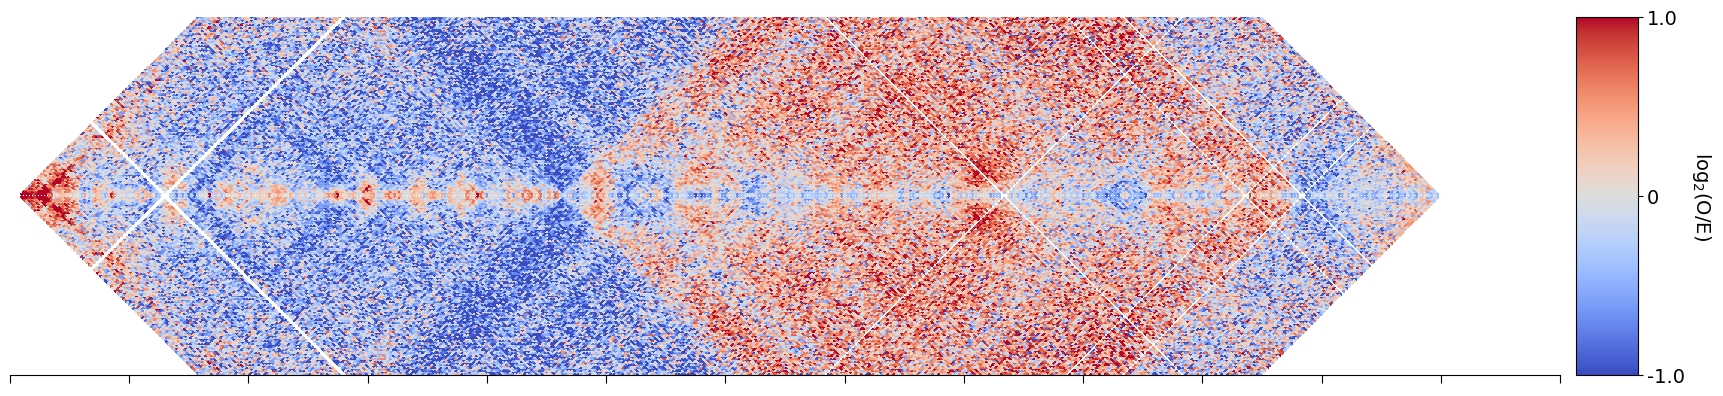

In [16]:
############## H1p1 treatment #############


import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
import bioframe
import os
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import itertools
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType — keeps text editable in Illustrator/Inkscape
mpl.rcParams['svg.fonttype'] = 'none'

# ── CONFIG ────────────────────────────────────────────────────────────────────
resolution  = 250_000
data_dir    = '/MyPath/'
cool_file   = 'DL-20250820-LCHCSeq-H1ESC-60mPDp10-DpnII-R3-T1__hg38.hg38.exclude1kb.1000.mcool'
region      = 'chr1:0-130,000,000'        # full chromosome
vmin, vmax  = -1.0, 1.0        # log2 O/E colour limits
cmap        = 'coolwarm'
# ─────────────────────────────────────────────────────────────────────────────

# ── LOAD COOLER ───────────────────────────────────────────────────────────────
clr = cooler.Cooler(f'{data_dir}/{cool_file}::/resolutions/{resolution}')

# ── COMPUTE EXPECTED (whole-genome arms table, then trim to chr) ──────────────
print(f"Fetching genome arms for expected calculation …")
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens       = bioframe.fetch_centromeres('hg38')
hg38_arms       = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
hg38_arms       = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

print(f"Computing expected for {region} …")
expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=4, ignore_diags=0)

print("Expected columns:", expected.columns.tolist())
print("Unique region1 values:", expected['region1'].unique()[:10])
print("Expected shape:", expected.shape)


# Parse region into chrom / start / end
parsed = bioframe.parse_region(region, clr.chromsizes)
reg_chrom, reg_start, reg_end = parsed[0], parsed[1], parsed[2]
print(f"Parsed region: {reg_chrom}:{reg_start:,}-{reg_end:,}")

# Keep only rows for our chromosome (match the arm(s) on this chrom)
expected_chr = expected[expected['region1'].str.startswith(reg_chrom)].copy()
print(f"expected_chr shape after filter: {expected_chr.shape}")
expected_vals = np.array(expected_chr['balanced.avg.smoothed'].values, dtype=np.float64)
print(f"expected_vals length: {len(expected_vals)}")
print(f"expected_vals NaN count: {np.sum(np.isnan(expected_vals))}")


# ── FETCH OBSERVED MATRIX (sub-region) ────────────────────────────────────────
print(f"Fetching observed matrix for {region} …")
obs = np.array(clr.matrix(balance=True).fetch(region), dtype=np.float64)
print(f"obs shape: {obs.shape}, non-NaN count: {np.sum(~np.isnan(obs))}")

# ── BUILD log2(O/E) MATRIX ────────────────────────────────────────────────────
print("Building log2(O/E) matrix …")
n = obs.shape[0]
oe = np.full_like(obs, np.nan)

for i in range(n):
    for j in range(i, n):
        d = j - i
        if d < len(expected_vals) and expected_vals[d] > 0:
            v = obs[i, j] / expected_vals[d]
            oe[i, j] = v
            oe[j, i] = v

log2oe = np.log2(oe)
log2oe[~np.isfinite(log2oe)] = np.nan   # Inf / -Inf → NaN

# ── 45-DEGREE ROTATION HELPER ────────────────────────────────────────────────
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, flip_y=False, **kwargs):
    n = matrix_c.shape[0]
    start_pos = [start + resolution * i for i in range(n + 1)]
    t = np.array([[1, 0.5], [-1, 0.5]])
    coords = np.array([(i[1], i[0])
                       for i in itertools.product(start_pos[::-1], start_pos)])
    mat = np.dot(coords, t)
    x = mat[:, 1].reshape(n + 1, n + 1)
    y = mat[:, 0].reshape(n + 1, n + 1)
    if flip_y:
        y = -y
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), **kwargs)
    im.set_rasterized(True)
    return im

# ── PLOT ──────────────────────────────────────────────────────────────────────
print("Plotting …")
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

f, ax = plt.subplots(figsize=(20, 8))

im  = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=False, norm=norm, cmap=cmap)
im2 = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=True,  norm=norm, cmap=cmap)

ax.set_ylim(-30_000_000, 30_000_000)
ax.set_aspect(0.5)

from matplotlib.ticker import MultipleLocator

ax.set_xlim(reg_start, reg_end)

# Tick marks every 10 Mb, no labels
ax.xaxis.set_major_locator(MultipleLocator(10_000_000))
ax.tick_params(axis='x', length=6, labelbottom=False)

# Hide y-axis and all spines
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Show only the bottom spine
for name, spine in ax.spines.items():
    spine.set_visible(name == 'bottom')

# Colorbar — same inset placement as original
cax = inset_axes(ax,
                 width="4%", height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.05, 0., 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('log$_2$(O/E)', rotation=270, labelpad=20, fontsize=14)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f'{vmin:.1f}', '0', f'{vmax:.1f}'])
cbar.ax.tick_params(labelsize=14)

safe = region.replace(':', '_').replace(',', '').replace('-', '_')
out_name = f'{cool_file[:-27]}.{safe}.{resolution//1000}kb.CraneHeatmap_log2OE.pdf'
plt.savefig(out_name, transparent=True, dpi=150)
print(f"Saved → {out_name}")
plt.show()

INFO:root:creating a Pool of 4 workers


Fetching genome arms for expected calculation …
Computing expected for chr1:0-130,000,000 …


/sharehome/dlafonta/miniconda3/envs/open2c-env/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


Expected columns: ['region1', 'region2', 'dist', 'dist_bp', 'contact_frequency', 'n_total', 'n_valid', 'count.sum', 'balanced.sum', 'count.avg', 'balanced.avg', 'balanced.avg.smoothed', 'balanced.avg.smoothed.agg']
Unique region1 values: ['chr1_p' 'chr1_q' 'chr2_p' 'chr2_q' 'chr3_p' 'chr3_q' 'chr4_p' 'chr4_q'
 'chr5_p' 'chr5_q']
Expected shape: (12383, 13)
Parsed region: chr1:0-130,000,000
expected_chr shape after filter: (5163, 13)
expected_vals length: 5163
expected_vals NaN count: 235
Fetching observed matrix for chr1:0-130,000,000 …
obs shape: (520, 520), non-NaN count: 221841
Building log2(O/E) matrix …


/tmp/ipykernel_2369817/1404255849.py:92: RuntimeWarning: divide by zero encountered in log2
  log2oe = np.log2(oe)


Plotting …


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 17 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 18, 19, 20, 21, 40, 50, 74, 79, 82]
INFO:fontTools.subset:Closed glyph list over 'MATH': 23 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'uni239B', 'uni239C

Saved → DL-20250820-LCHCSeq-H1ESC-60mPDp25-DpnII-R3-T1__hg38.chr1_0_130000000.250kb.CraneHeatmap_log2OE.pdf


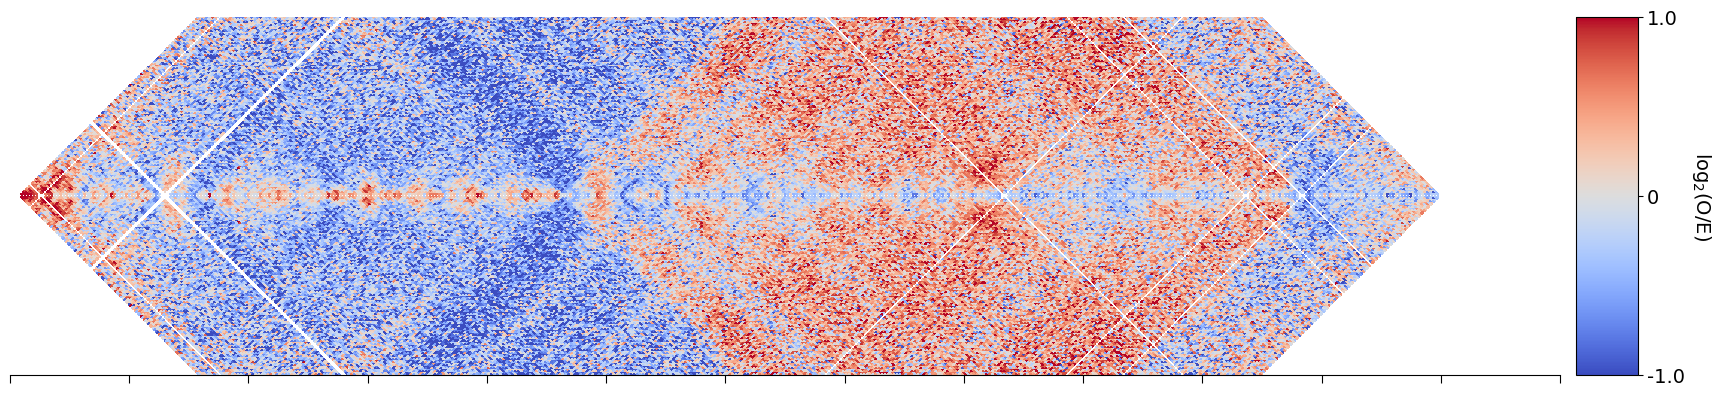

In [1]:
############## H1 1h treatment #############


import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
import bioframe
import os
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import itertools
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType — keeps text editable in Illustrator/Inkscape
mpl.rcParams['svg.fonttype'] = 'none'

# ── CONFIG ────────────────────────────────────────────────────────────────────
resolution  = 250_000
data_dir    = '/MyPath/'
cool_file   = 'DL-20250820-LCHCSeq-H1ESC-60mPDp25-DpnII-R3-T1__hg38.hg38.exclude1kb.1000.mcool'
region      = 'chr1:0-130,000,000'        # full chromosome
vmin, vmax  = -1.0, 1.0        # log2 O/E colour limits
cmap        = 'coolwarm'
# ─────────────────────────────────────────────────────────────────────────────

# ── LOAD COOLER ───────────────────────────────────────────────────────────────
clr = cooler.Cooler(f'{data_dir}/{cool_file}::/resolutions/{resolution}')

# ── COMPUTE EXPECTED (whole-genome arms table, then trim to chr) ──────────────
print(f"Fetching genome arms for expected calculation …")
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens       = bioframe.fetch_centromeres('hg38')
hg38_arms       = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
hg38_arms       = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

print(f"Computing expected for {region} …")
expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=4, ignore_diags=0)

print("Expected columns:", expected.columns.tolist())
print("Unique region1 values:", expected['region1'].unique()[:10])
print("Expected shape:", expected.shape)


# Parse region into chrom / start / end
parsed = bioframe.parse_region(region, clr.chromsizes)
reg_chrom, reg_start, reg_end = parsed[0], parsed[1], parsed[2]
print(f"Parsed region: {reg_chrom}:{reg_start:,}-{reg_end:,}")

# Keep only rows for our chromosome (match the arm(s) on this chrom)
expected_chr = expected[expected['region1'].str.startswith(reg_chrom)].copy()
print(f"expected_chr shape after filter: {expected_chr.shape}")
expected_vals = np.array(expected_chr['balanced.avg.smoothed'].values, dtype=np.float64)
print(f"expected_vals length: {len(expected_vals)}")
print(f"expected_vals NaN count: {np.sum(np.isnan(expected_vals))}")

# ── FETCH OBSERVED MATRIX (sub-region) ────────────────────────────────────────
print(f"Fetching observed matrix for {region} …")
obs = np.array(clr.matrix(balance=True).fetch(region), dtype=np.float64)
print(f"obs shape: {obs.shape}, non-NaN count: {np.sum(~np.isnan(obs))}")

# ── BUILD log2(O/E) MATRIX ────────────────────────────────────────────────────
print("Building log2(O/E) matrix …")
n = obs.shape[0]
oe = np.full_like(obs, np.nan)

for i in range(n):
    for j in range(i, n):
        d = j - i
        if d < len(expected_vals) and expected_vals[d] > 0:
            v = obs[i, j] / expected_vals[d]
            oe[i, j] = v
            oe[j, i] = v

log2oe = np.log2(oe)
log2oe[~np.isfinite(log2oe)] = np.nan   # Inf / -Inf → NaN

# ── 45-DEGREE ROTATION HELPER ────────────────────────────────────────────────
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, flip_y=False, **kwargs):
    n = matrix_c.shape[0]
    start_pos = [start + resolution * i for i in range(n + 1)]
    t = np.array([[1, 0.5], [-1, 0.5]])
    coords = np.array([(i[1], i[0])
                       for i in itertools.product(start_pos[::-1], start_pos)])
    mat = np.dot(coords, t)
    x = mat[:, 1].reshape(n + 1, n + 1)
    y = mat[:, 0].reshape(n + 1, n + 1)
    if flip_y:
        y = -y
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), **kwargs)
    im.set_rasterized(True)
    return im

# ── PLOT ──────────────────────────────────────────────────────────────────────
print("Plotting …")
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

f, ax = plt.subplots(figsize=(20, 8))

im  = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=False, norm=norm, cmap=cmap)
im2 = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=True,  norm=norm, cmap=cmap)

ax.set_ylim(-30_000_000, 30_000_000)
ax.set_aspect(0.5)

from matplotlib.ticker import MultipleLocator

ax.set_xlim(reg_start, reg_end)

# Tick marks every 10 Mb, no labels
ax.xaxis.set_major_locator(MultipleLocator(10_000_000))
ax.tick_params(axis='x', length=6, labelbottom=False)

# Hide y-axis and all spines
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Show only the bottom spine
for name, spine in ax.spines.items():
    spine.set_visible(name == 'bottom')

# Colorbar — same inset placement as original
cax = inset_axes(ax,
                 width="4%", height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.05, 0., 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('log$_2$(O/E)', rotation=270, labelpad=20, fontsize=14)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f'{vmin:.1f}', '0', f'{vmax:.1f}'])
cbar.ax.tick_params(labelsize=14)

safe = region.replace(':', '_').replace(',', '').replace('-', '_')
out_name = f'{cool_file[:-27]}.{safe}.{resolution//1000}kb.CraneHeatmap_log2OE.pdf'
plt.savefig(out_name, transparent=True, dpi=150)
print(f"Saved → {out_name}")
plt.show()

INFO:root:creating a Pool of 4 workers


Fetching genome arms for expected calculation …
Computing expected for chr1:0-130,000,000 …


/sharehome/dlafonta/miniconda3/envs/open2c-env/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


Expected columns: ['region1', 'region2', 'dist', 'dist_bp', 'contact_frequency', 'n_total', 'n_valid', 'count.sum', 'balanced.sum', 'count.avg', 'balanced.avg', 'balanced.avg.smoothed', 'balanced.avg.smoothed.agg']
Unique region1 values: ['chr1_p' 'chr1_q' 'chr2_p' 'chr2_q' 'chr3_p' 'chr3_q' 'chr4_p' 'chr4_q'
 'chr5_p' 'chr5_q']
Expected shape: (12383, 13)
Parsed region: chr1:0-130,000,000
expected_chr shape after filter: (5163, 13)
expected_vals length: 5163
expected_vals NaN count: 235
Fetching observed matrix for chr1:0-130,000,000 …
obs shape: (520, 520), non-NaN count: 222784
Building log2(O/E) matrix …


/tmp/ipykernel_749576/1354251342.py:92: RuntimeWarning: divide by zero encountered in log2
  log2oe = np.log2(oe)


Plotting …


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 17 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 18, 19, 20, 21, 40, 50, 74, 79, 82]
INFO:fontTools.subset:Closed glyph list over 'MATH': 23 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'uni239B', 'uni239C

Saved → DL-20260616-LCHCSeq-DE-120mPD-DpnII-R2-T1__hg38.chr1_0_130000000.250kb.CraneHeatmap_log2OE.pdf


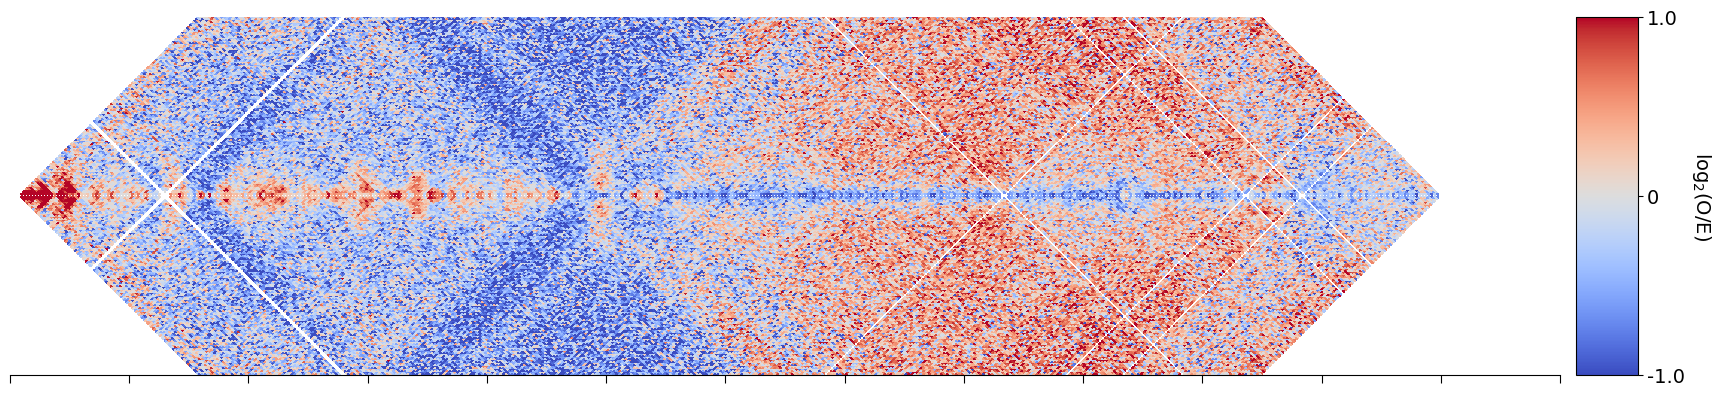

In [2]:
############## DER2 treatment #############


import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
import bioframe
import os
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import itertools
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType — keeps text editable in Illustrator/Inkscape
mpl.rcParams['svg.fonttype'] = 'none'

# ── CONFIG ────────────────────────────────────────────────────────────────────
resolution  = 250_000
data_dir    = '/MyPath/'
cool_file   = 'DL-20260616-LCHCSeq-DE-120mPD-DpnII-R2-T1__hg38.hg38.exclude1kb.1000.mcool'
region      = 'chr1:0-130,000,000'        # full chromosome
vmin, vmax  = -1.0, 1.0        # log2 O/E colour limits
cmap        = 'coolwarm'
# ─────────────────────────────────────────────────────────────────────────────

# ── LOAD COOLER ───────────────────────────────────────────────────────────────
clr = cooler.Cooler(f'{data_dir}/{cool_file}::/resolutions/{resolution}')

# ── COMPUTE EXPECTED (whole-genome arms table, then trim to chr) ──────────────
print(f"Fetching genome arms for expected calculation …")
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens       = bioframe.fetch_centromeres('hg38')
hg38_arms       = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
hg38_arms       = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

print(f"Computing expected for {region} …")
expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=4, ignore_diags=0)

print("Expected columns:", expected.columns.tolist())
print("Unique region1 values:", expected['region1'].unique()[:10])
print("Expected shape:", expected.shape)


# Parse region into chrom / start / end
parsed = bioframe.parse_region(region, clr.chromsizes)
reg_chrom, reg_start, reg_end = parsed[0], parsed[1], parsed[2]
print(f"Parsed region: {reg_chrom}:{reg_start:,}-{reg_end:,}")

# Keep only rows for our chromosome (match the arm(s) on this chrom)
expected_chr = expected[expected['region1'].str.startswith(reg_chrom)].copy()
print(f"expected_chr shape after filter: {expected_chr.shape}")
expected_vals = np.array(expected_chr['balanced.avg.smoothed'].values, dtype=np.float64)
print(f"expected_vals length: {len(expected_vals)}")
print(f"expected_vals NaN count: {np.sum(np.isnan(expected_vals))}")

# ── FETCH OBSERVED MATRIX (sub-region) ────────────────────────────────────────
print(f"Fetching observed matrix for {region} …")
obs = np.array(clr.matrix(balance=True).fetch(region), dtype=np.float64)
print(f"obs shape: {obs.shape}, non-NaN count: {np.sum(~np.isnan(obs))}")

# ── BUILD log2(O/E) MATRIX ────────────────────────────────────────────────────
print("Building log2(O/E) matrix …")
n = obs.shape[0]
oe = np.full_like(obs, np.nan)

for i in range(n):
    for j in range(i, n):
        d = j - i
        if d < len(expected_vals) and expected_vals[d] > 0:
            v = obs[i, j] / expected_vals[d]
            oe[i, j] = v
            oe[j, i] = v

log2oe = np.log2(oe)
log2oe[~np.isfinite(log2oe)] = np.nan   # Inf / -Inf → NaN

# ── 45-DEGREE ROTATION HELPER ────────────────────────────────────────────────
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, flip_y=False, **kwargs):
    n = matrix_c.shape[0]
    start_pos = [start + resolution * i for i in range(n + 1)]
    t = np.array([[1, 0.5], [-1, 0.5]])
    coords = np.array([(i[1], i[0])
                       for i in itertools.product(start_pos[::-1], start_pos)])
    mat = np.dot(coords, t)
    x = mat[:, 1].reshape(n + 1, n + 1)
    y = mat[:, 0].reshape(n + 1, n + 1)
    if flip_y:
        y = -y
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), **kwargs)
    im.set_rasterized(True)
    return im

# ── PLOT ──────────────────────────────────────────────────────────────────────
print("Plotting …")
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

f, ax = plt.subplots(figsize=(20, 8))

im  = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=False, norm=norm, cmap=cmap)
im2 = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=True,  norm=norm, cmap=cmap)

ax.set_ylim(-30_000_000, 30_000_000)
ax.set_aspect(0.5)

from matplotlib.ticker import MultipleLocator

ax.set_xlim(reg_start, reg_end)

# Tick marks every 10 Mb, no labels
ax.xaxis.set_major_locator(MultipleLocator(10_000_000))
ax.tick_params(axis='x', length=6, labelbottom=False)

# Hide y-axis and all spines
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Show only the bottom spine
for name, spine in ax.spines.items():
    spine.set_visible(name == 'bottom')

# Colorbar — same inset placement as original
cax = inset_axes(ax,
                 width="4%", height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.05, 0., 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('log$_2$(O/E)', rotation=270, labelpad=20, fontsize=14)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f'{vmin:.1f}', '0', f'{vmax:.1f}'])
cbar.ax.tick_params(labelsize=14)

safe = region.replace(':', '_').replace(',', '').replace('-', '_')
out_name = f'{cool_file[:-27]}.{safe}.{resolution//1000}kb.CraneHeatmap_log2OE.pdf'
plt.savefig(out_name, transparent=True, dpi=150)
print(f"Saved → {out_name}")
plt.show()

INFO:root:creating a Pool of 4 workers


Fetching genome arms for expected calculation …
Computing expected for chr1:0-130,000,000 …


/sharehome/dlafonta/miniconda3/envs/open2c-env/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


Expected columns: ['region1', 'region2', 'dist', 'dist_bp', 'contact_frequency', 'n_total', 'n_valid', 'count.sum', 'balanced.sum', 'count.avg', 'balanced.avg', 'balanced.avg.smoothed', 'balanced.avg.smoothed.agg']
Unique region1 values: ['chr1_p' 'chr1_q' 'chr2_p' 'chr2_q' 'chr3_p' 'chr3_q' 'chr4_p' 'chr4_q'
 'chr5_p' 'chr5_q']
Expected shape: (12383, 13)
Parsed region: chr1:0-130,000,000
expected_chr shape after filter: (5163, 13)
expected_vals length: 5163
expected_vals NaN count: 235
Fetching observed matrix for chr1:0-130,000,000 …
obs shape: (520, 520), non-NaN count: 221841
Building log2(O/E) matrix …


/tmp/ipykernel_2369817/3033006307.py:92: RuntimeWarning: divide by zero encountered in log2
  log2oe = np.log2(oe)


Plotting …


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 17 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 18, 19, 20, 21, 40, 50, 74, 79, 82]
INFO:fontTools.subset:Closed glyph list over 'MATH': 23 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'uni239B', 'uni239C

Saved → DL-20250820-LCHCSeq-H1ESC-60mPDp05-DpnII-R3-T1__hg38.chr1_0_130000000.250kb.CraneHeatmap_log2OE.pdf


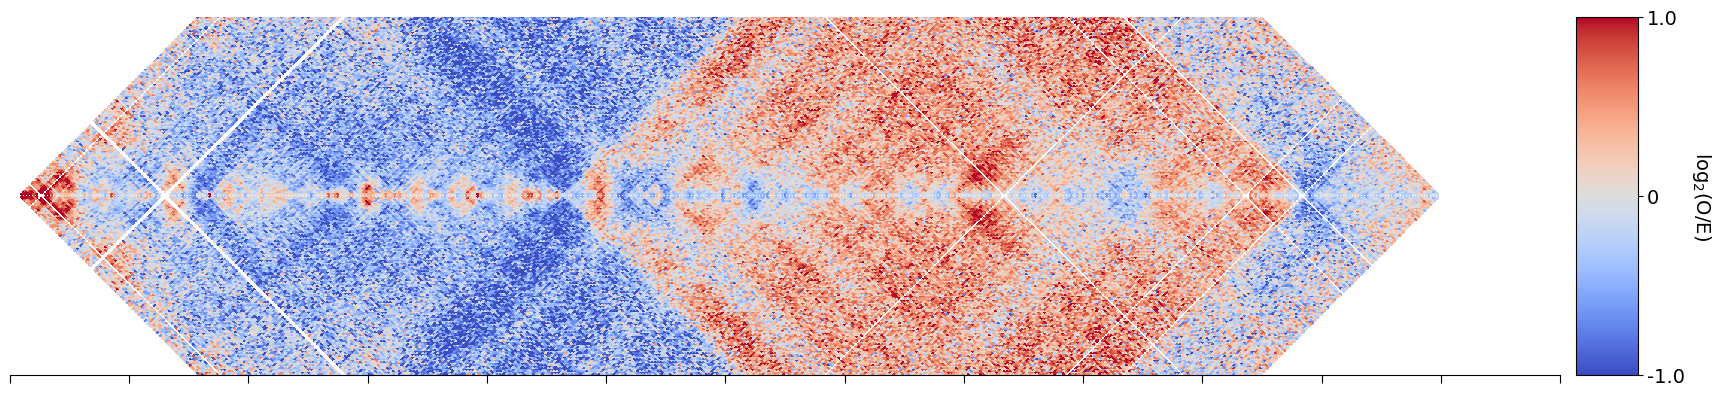

In [2]:
############## H1p05 treatment #############


import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
import bioframe
import os
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import itertools
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType — keeps text editable in Illustrator/Inkscape
mpl.rcParams['svg.fonttype'] = 'none'

# ── CONFIG ────────────────────────────────────────────────────────────────────
resolution  = 250_000
data_dir    = '/MyPath/'
cool_file   = 'DL-20250820-LCHCSeq-H1ESC-60mPDp05-DpnII-R3-T1__hg38.hg38.exclude1kb.1000.mcool'
region      = 'chr1:0-130,000,000'        # full chromosome
vmin, vmax  = -1.0, 1.0        # log2 O/E colour limits
cmap        = 'coolwarm'
# ─────────────────────────────────────────────────────────────────────────────

# ── LOAD COOLER ───────────────────────────────────────────────────────────────
clr = cooler.Cooler(f'{data_dir}/{cool_file}::/resolutions/{resolution}')

# ── COMPUTE EXPECTED (whole-genome arms table, then trim to chr) ──────────────
print(f"Fetching genome arms for expected calculation …")
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens       = bioframe.fetch_centromeres('hg38')
hg38_arms       = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
hg38_arms       = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

print(f"Computing expected for {region} …")
expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=4, ignore_diags=0)

print("Expected columns:", expected.columns.tolist())
print("Unique region1 values:", expected['region1'].unique()[:10])
print("Expected shape:", expected.shape)


# Parse region into chrom / start / end
parsed = bioframe.parse_region(region, clr.chromsizes)
reg_chrom, reg_start, reg_end = parsed[0], parsed[1], parsed[2]
print(f"Parsed region: {reg_chrom}:{reg_start:,}-{reg_end:,}")

# Keep only rows for our chromosome (match the arm(s) on this chrom)
expected_chr = expected[expected['region1'].str.startswith(reg_chrom)].copy()
print(f"expected_chr shape after filter: {expected_chr.shape}")
expected_vals = np.array(expected_chr['balanced.avg.smoothed'].values, dtype=np.float64)
print(f"expected_vals length: {len(expected_vals)}")
print(f"expected_vals NaN count: {np.sum(np.isnan(expected_vals))}")

# ── FETCH OBSERVED MATRIX (sub-region) ────────────────────────────────────────
print(f"Fetching observed matrix for {region} …")
obs = np.array(clr.matrix(balance=True).fetch(region), dtype=np.float64)
print(f"obs shape: {obs.shape}, non-NaN count: {np.sum(~np.isnan(obs))}")

# ── BUILD log2(O/E) MATRIX ────────────────────────────────────────────────────
print("Building log2(O/E) matrix …")
n = obs.shape[0]
oe = np.full_like(obs, np.nan)

for i in range(n):
    for j in range(i, n):
        d = j - i
        if d < len(expected_vals) and expected_vals[d] > 0:
            v = obs[i, j] / expected_vals[d]
            oe[i, j] = v
            oe[j, i] = v

log2oe = np.log2(oe)
log2oe[~np.isfinite(log2oe)] = np.nan   # Inf / -Inf → NaN

# ── 45-DEGREE ROTATION HELPER ────────────────────────────────────────────────
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, flip_y=False, **kwargs):
    n = matrix_c.shape[0]
    start_pos = [start + resolution * i for i in range(n + 1)]
    t = np.array([[1, 0.5], [-1, 0.5]])
    coords = np.array([(i[1], i[0])
                       for i in itertools.product(start_pos[::-1], start_pos)])
    mat = np.dot(coords, t)
    x = mat[:, 1].reshape(n + 1, n + 1)
    y = mat[:, 0].reshape(n + 1, n + 1)
    if flip_y:
        y = -y
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), **kwargs)
    im.set_rasterized(True)
    return im

# ── PLOT ──────────────────────────────────────────────────────────────────────
print("Plotting …")
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

f, ax = plt.subplots(figsize=(20, 8))

im  = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=False, norm=norm, cmap=cmap)
im2 = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=True,  norm=norm, cmap=cmap)

ax.set_ylim(-30_000_000, 30_000_000)
ax.set_aspect(0.5)

from matplotlib.ticker import MultipleLocator

ax.set_xlim(reg_start, reg_end)

# Tick marks every 10 Mb, no labels
ax.xaxis.set_major_locator(MultipleLocator(10_000_000))
ax.tick_params(axis='x', length=6, labelbottom=False)

# Hide y-axis and all spines
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Show only the bottom spine
for name, spine in ax.spines.items():
    spine.set_visible(name == 'bottom')

# Colorbar — same inset placement as original
cax = inset_axes(ax,
                 width="4%", height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.05, 0., 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('log$_2$(O/E)', rotation=270, labelpad=20, fontsize=14)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f'{vmin:.1f}', '0', f'{vmax:.1f}'])
cbar.ax.tick_params(labelsize=14)

safe = region.replace(':', '_').replace(',', '').replace('-', '_')
out_name = f'{cool_file[:-27]}.{safe}.{resolution//1000}kb.CraneHeatmap_log2OE.pdf'
plt.savefig(out_name, transparent=True, dpi=150)
print(f"Saved → {out_name}")
plt.show()

INFO:root:creating a Pool of 4 workers


Fetching genome arms for expected calculation …
Computing expected for chr1:0-130,000,000 …


/sharehome/dlafonta/miniconda3/envs/open2c-env/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


Expected columns: ['region1', 'region2', 'dist', 'dist_bp', 'contact_frequency', 'n_total', 'n_valid', 'count.sum', 'balanced.sum', 'count.avg', 'balanced.avg', 'balanced.avg.smoothed', 'balanced.avg.smoothed.agg']
Unique region1 values: ['chr1_p' 'chr1_q' 'chr2_p' 'chr2_q' 'chr3_p' 'chr3_q' 'chr4_p' 'chr4_q'
 'chr5_p' 'chr5_q']
Expected shape: (12383, 13)
Parsed region: chr1:0-130,000,000
expected_chr shape after filter: (5163, 13)
expected_vals length: 5163
expected_vals NaN count: 235
Fetching observed matrix for chr1:0-130,000,000 …
obs shape: (520, 520), non-NaN count: 217156
Building log2(O/E) matrix …
Plotting …


/tmp/ipykernel_2101033/1163691736.py:92: RuntimeWarning: divide by zero encountered in log2
  log2oe = np.log2(oe)
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 17 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'slash', 'space', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 18, 19, 20, 21, 40, 50, 74, 79, 82]
INFO:fontTools.subset:Closed glyph list over 'MATH': 23 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'E', 'O', 'g', 'hyphen', 'l'

Saved → DL-20250326-LCHCSeq-mHep-2hPD-DpnII-R2-T1__hg38.chr1_0_130000000.250kb.CraneHeatmap_log2OE.pdf


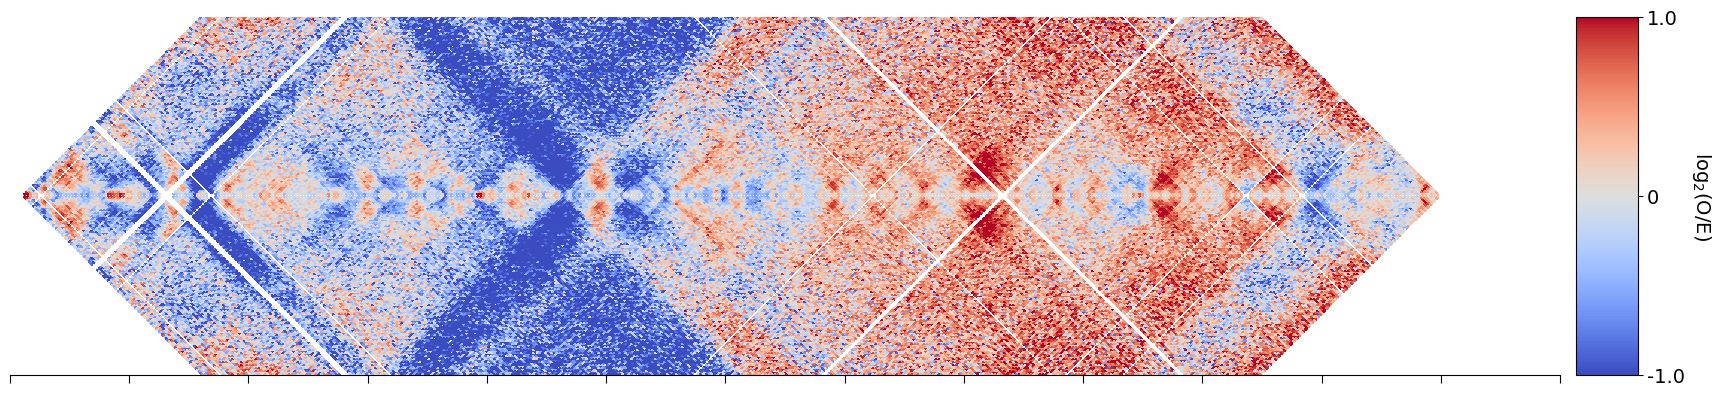

In [1]:
############## mHepR1 treatment #############


import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
import bioframe
import os
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import itertools
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType — keeps text editable in Illustrator/Inkscape
mpl.rcParams['svg.fonttype'] = 'none'

# ── CONFIG ────────────────────────────────────────────────────────────────────
resolution  = 250_000
data_dir    = '/MyPath/'
cool_file   = 'DL-20250326-LCHCSeq-mHep-2hPD-DpnII-R2-T1__hg38.hg38.exclude1kb.1000.mcool'
region      = 'chr1:0-130,000,000'        # full chromosome
vmin, vmax  = -1.0, 1.0        # log2 O/E colour limits
cmap        = 'coolwarm'
# ─────────────────────────────────────────────────────────────────────────────

# ── LOAD COOLER ───────────────────────────────────────────────────────────────
clr = cooler.Cooler(f'{data_dir}/{cool_file}::/resolutions/{resolution}')

# ── COMPUTE EXPECTED (whole-genome arms table, then trim to chr) ──────────────
print(f"Fetching genome arms for expected calculation …")
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens       = bioframe.fetch_centromeres('hg38')
hg38_arms       = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
hg38_arms       = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

print(f"Computing expected for {region} …")
expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=4, ignore_diags=0)

print("Expected columns:", expected.columns.tolist())
print("Unique region1 values:", expected['region1'].unique()[:10])
print("Expected shape:", expected.shape)


# Parse region into chrom / start / end
parsed = bioframe.parse_region(region, clr.chromsizes)
reg_chrom, reg_start, reg_end = parsed[0], parsed[1], parsed[2]
print(f"Parsed region: {reg_chrom}:{reg_start:,}-{reg_end:,}")

# Keep only rows for our chromosome (match the arm(s) on this chrom)
expected_chr = expected[expected['region1'].str.startswith(reg_chrom)].copy()
print(f"expected_chr shape after filter: {expected_chr.shape}")
expected_vals = np.array(expected_chr['balanced.avg.smoothed'].values, dtype=np.float64)
print(f"expected_vals length: {len(expected_vals)}")
print(f"expected_vals NaN count: {np.sum(np.isnan(expected_vals))}")

# ── FETCH OBSERVED MATRIX (sub-region) ────────────────────────────────────────
print(f"Fetching observed matrix for {region} …")
obs = np.array(clr.matrix(balance=True).fetch(region), dtype=np.float64)
print(f"obs shape: {obs.shape}, non-NaN count: {np.sum(~np.isnan(obs))}")

# ── BUILD log2(O/E) MATRIX ────────────────────────────────────────────────────
print("Building log2(O/E) matrix …")
n = obs.shape[0]
oe = np.full_like(obs, np.nan)

for i in range(n):
    for j in range(i, n):
        d = j - i
        if d < len(expected_vals) and expected_vals[d] > 0:
            v = obs[i, j] / expected_vals[d]
            oe[i, j] = v
            oe[j, i] = v

log2oe = np.log2(oe)
log2oe[~np.isfinite(log2oe)] = np.nan   # Inf / -Inf → NaN

# ── 45-DEGREE ROTATION HELPER ────────────────────────────────────────────────
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, flip_y=False, **kwargs):
    n = matrix_c.shape[0]
    start_pos = [start + resolution * i for i in range(n + 1)]
    t = np.array([[1, 0.5], [-1, 0.5]])
    coords = np.array([(i[1], i[0])
                       for i in itertools.product(start_pos[::-1], start_pos)])
    mat = np.dot(coords, t)
    x = mat[:, 1].reshape(n + 1, n + 1)
    y = mat[:, 0].reshape(n + 1, n + 1)
    if flip_y:
        y = -y
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), **kwargs)
    im.set_rasterized(True)
    return im

# ── PLOT ──────────────────────────────────────────────────────────────────────
print("Plotting …")
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

f, ax = plt.subplots(figsize=(20, 8))

im  = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=False, norm=norm, cmap=cmap)
im2 = pcolormesh_45deg(ax, log2oe, start=reg_start, resolution=resolution,
                       flip_y=True,  norm=norm, cmap=cmap)

ax.set_ylim(-30_000_000, 30_000_000)
ax.set_aspect(0.5)

from matplotlib.ticker import MultipleLocator

ax.set_xlim(reg_start, reg_end)

# Tick marks every 10 Mb, no labels
ax.xaxis.set_major_locator(MultipleLocator(10_000_000))
ax.tick_params(axis='x', length=6, labelbottom=False)

# Hide y-axis and all spines
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Show only the bottom spine
for name, spine in ax.spines.items():
    spine.set_visible(name == 'bottom')

# Colorbar — same inset placement as original
cax = inset_axes(ax,
                 width="4%", height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.05, 0., 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('log$_2$(O/E)', rotation=270, labelpad=20, fontsize=14)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f'{vmin:.1f}', '0', f'{vmax:.1f}'])
cbar.ax.tick_params(labelsize=14)

safe = region.replace(':', '_').replace(',', '').replace('-', '_')
out_name = f'{cool_file[:-27]}.{safe}.{resolution//1000}kb.CraneHeatmap_log2OE.pdf'
plt.savefig(out_name, transparent=True, dpi=150)
print(f"Saved → {out_name}")
plt.show()